Now let's not assume we have an institution backing us up, ie we have to now trade like we cannot short long

In [1]:
import pandas as pd
z_scores = pd.read_csv('/Users/dhairya/cs projects/DS303 final project/dataset/z_scores.csv')
cluster_and_price_data = pd.read_csv('/Users/dhairya/cs projects/DS303 final project/dataset/cluster_price_data.csv')

In [5]:
positions = {}  # Track number of shares held for each stock
buy_signals = pd.DataFrame(0, index=z_scores.index, columns=z_scores.columns)
sell_signals = pd.DataFrame(0, index=z_scores.index, columns=z_scores.columns)

for column in z_scores.columns:
    if column != 'Date':
        positions[column] = 0
        
        for idx in z_scores.index:
            z_score = z_scores.loc[idx, column]
            
            if z_score > 3:
                buy_signals.loc[idx, column] = 1
                positions[column] += 1
                
            elif z_score < -3 and positions[column] > 0:
                sell_signals.loc[idx, column] = 1
                positions[column] -= 1

print("Buy Signals:")
print(buy_signals.sum())
print("\nSell Signals:")
print(sell_signals.sum())
print("\nFinal Positions:")
print(pd.Series(positions))

Buy Signals:
Date                     0
20MICRONS_closing_0      0
ADANIPOWER_closing_0     4
ALKALI_closing_0         4
APCL_closing_0           0
                        ..
WONDERLA_closing_4       0
WSTCSTPAPR_closing_4     0
YAARI_closing_4         26
ZODIAC_closing_4        30
ZODIACLOTH_closing_4    30
Length: 1263, dtype: int64

Sell Signals:
Date                    0
20MICRONS_closing_0     0
ADANIPOWER_closing_0    0
ALKALI_closing_0        0
APCL_closing_0          0
                       ..
WONDERLA_closing_4      0
WSTCSTPAPR_closing_4    0
YAARI_closing_4         0
ZODIAC_closing_4        0
ZODIACLOTH_closing_4    0
Length: 1263, dtype: int64

Final Positions:
20MICRONS_closing_0      0
ADANIPOWER_closing_0     4
ALKALI_closing_0         4
APCL_closing_0           0
APTECHT_closing_0        0
                        ..
WONDERLA_closing_4       0
WSTCSTPAPR_closing_4     0
YAARI_closing_4         26
ZODIAC_closing_4        30
ZODIACLOTH_closing_4    30
Length: 1262, dtype:

In [7]:
signals = pd.DataFrame(0, index=z_scores.index, columns=z_scores.columns)

for column in z_scores.columns:
    if column != 'Date':
        position = 0
        for idx in z_scores.index:
            z_score = z_scores.loc[idx, column]
            
            if z_score > 3:
                signals.loc[idx, column] = 1
                position += 1
            elif z_score < -3 and position > 0:
                signals.loc[idx, column] = -1
                position -= 1

In [8]:
signals

,Date,20MICRONS_closing_0,ADANIPOWER_closing_0,ALKALI_closing_0,APCL_closing_0,APTECHT_closing_0,ARIES_closing_0,AVADHSUGAR_closing_0,AVTNPL_closing_0,BAJAJHIND_closing_0,...,VOLTAMP_closing_4,VSSL_closing_4,VTL_closing_4,WABAG_closing_4,WELCORP_closing_4,WONDERLA_closing_4,WSTCSTPAPR_closing_4,YAARI_closing_4,ZODIAC_closing_4,ZODIACLOTH_closing_4
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
490,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
491,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
signals_c_sum = signals.cumsum()

In [12]:
signals_c_sum

,Date,20MICRONS_closing_0,ADANIPOWER_closing_0,ALKALI_closing_0,APCL_closing_0,APTECHT_closing_0,ARIES_closing_0,AVADHSUGAR_closing_0,AVTNPL_closing_0,BAJAJHIND_closing_0,...,VOLTAMP_closing_4,VSSL_closing_4,VTL_closing_4,WABAG_closing_4,WELCORP_closing_4,WONDERLA_closing_4,WSTCSTPAPR_closing_4,YAARI_closing_4,ZODIAC_closing_4,ZODIACLOTH_closing_4
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,0,0,4,4,0,0,0,0,0,5,...,0,0,0,0,0,0,0,26,30,30
489,0,0,4,4,0,0,0,0,0,5,...,0,0,0,0,0,0,0,26,30,30
490,0,0,4,4,0,0,0,0,0,5,...,0,0,0,0,0,0,0,26,30,30
491,0,0,4,4,0,0,0,0,0,5,...,0,0,0,0,0,0,0,26,30,30


In [13]:
cluster_and_price_data

,Date,20MICRONS_closing_0,3MINDIA_closing_2,5PAISA_closing_3,63MOONS_closing_1,A2ZINFRA_closing_1,AARTIDRUGS_closing_3,AARVEEDEN_closing_1,AAVAS_closing_2,ABB_closing_2,...,ZEELEARN_closing_1,ZEEMEDIA_closing_1,ZENSARTECH_closing_3,ZENTEC_closing_1,ZODIAC_closing_4,ZODIACLOTH_closing_4,ZOTA_closing_3,ZUARI_closing_0,ZUARIGLOB_closing_0,ZYDUSWELL_closing_3
0,2020-01-02,35.55,21381.15,211.30,110.30,8.20,147.55,14.30,1987.90,1294.20,...,19.15,6.05,180.30,57.25,172.25,172.25,189.90,58.20,58.20,1473.80
1,2020-01-06,32.80,21089.70,198.05,104.20,8.05,140.54,14.15,1990.20,1287.00,...,19.45,5.90,181.95,57.85,167.20,167.20,185.85,61.30,61.30,1438.05
2,2020-01-07,33.20,21660.40,204.75,107.75,8.20,143.28,13.95,1970.80,1306.75,...,20.00,6.00,184.00,58.90,171.20,171.20,186.40,73.55,73.55,1428.50
3,2020-01-08,32.70,21238.05,195.95,105.55,8.00,141.28,13.95,1938.55,1310.70,...,19.60,6.00,183.90,58.20,169.75,169.75,185.50,72.50,72.50,1446.70
4,2020-01-09,33.40,21272.20,195.50,107.80,7.95,144.81,14.10,1978.35,1322.10,...,19.35,5.95,184.85,60.45,171.90,171.90,185.35,68.95,68.95,1454.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,2021-12-27,57.10,24963.40,407.60,207.15,7.90,523.00,29.55,2488.45,2195.50,...,13.90,12.55,470.10,215.30,105.95,105.95,395.95,134.70,134.70,1859.85
489,2021-12-28,59.75,24969.40,407.70,217.50,8.25,519.15,31.00,2490.30,2207.10,...,14.05,13.15,498.70,216.75,107.80,107.80,398.10,140.10,140.10,1920.70
490,2021-12-29,59.60,24950.05,405.50,228.35,8.65,528.75,29.45,2551.05,2226.60,...,13.95,12.95,524.60,215.40,107.00,107.00,395.65,142.60,142.60,1903.40
491,2021-12-30,62.35,25047.00,393.40,217.30,9.05,522.70,28.35,2575.75,2235.40,...,14.70,12.80,518.70,216.70,108.00,108.00,394.35,140.85,140.85,1901.25


In [19]:
buy_at = pd.DataFrame(0, index=signals.index, columns=signals.columns)

for column in signals.columns:
    if column != 'Date':
        buy_at[column] = signals[column] * cluster_and_price_data[column]


In [20]:
buy_at = buy_at.cumsum()

In [21]:
curr_portfolio = pd.DataFrame(0, index=signals.index, columns=signals.columns)

for column in signals_c_sum.columns:
    if column != 'Date':
        curr_portfolio[column] = signals_c_sum[column] * cluster_and_price_data[column]


In [22]:
curr_portfolio

,Date,20MICRONS_closing_0,ADANIPOWER_closing_0,ALKALI_closing_0,APCL_closing_0,APTECHT_closing_0,ARIES_closing_0,AVADHSUGAR_closing_0,AVTNPL_closing_0,BAJAJHIND_closing_0,...,VOLTAMP_closing_4,VSSL_closing_4,VTL_closing_4,WABAG_closing_4,WELCORP_closing_4,WONDERLA_closing_4,WSTCSTPAPR_closing_4,YAARI_closing_4,ZODIAC_closing_4,ZODIACLOTH_closing_4
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,0,0.0,397.8,2456.8,0.0,0.0,0.0,0.0,0.0,71.50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2355.6,3178.5,3178.5
489,0,0.0,404.0,2524.6,0.0,0.0,0.0,0.0,0.0,75.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2369.9,3234.0,3234.0
490,0,0.0,399.4,2564.0,0.0,0.0,0.0,0.0,0.0,74.50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2351.7,3210.0,3210.0
491,0,0.0,397.8,2599.8,0.0,0.0,0.0,0.0,0.0,73.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2333.5,3240.0,3240.0


In [23]:
buy_at

,Date,20MICRONS_closing_0,ADANIPOWER_closing_0,ALKALI_closing_0,APCL_closing_0,APTECHT_closing_0,ARIES_closing_0,AVADHSUGAR_closing_0,AVTNPL_closing_0,BAJAJHIND_closing_0,...,VOLTAMP_closing_4,VSSL_closing_4,VTL_closing_4,WABAG_closing_4,WELCORP_closing_4,WONDERLA_closing_4,WSTCSTPAPR_closing_4,YAARI_closing_4,ZODIAC_closing_4,ZODIACLOTH_closing_4
0,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00
1,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00
2,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00
3,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00
4,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,0,0.0,606.5,3183.85,0.0,0.0,0.0,0.0,0.0,115.95,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4001.55,3772.35,3772.35
489,0,0.0,606.5,3183.85,0.0,0.0,0.0,0.0,0.0,115.95,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4001.55,3772.35,3772.35
490,0,0.0,606.5,3183.85,0.0,0.0,0.0,0.0,0.0,115.95,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4001.55,3772.35,3772.35
491,0,0.0,606.5,3183.85,0.0,0.0,0.0,0.0,0.0,115.95,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4001.55,3772.35,3772.35


In [24]:
profit_normal_trading = buy_at - curr_portfolio

In [27]:
profit_normal_trading = profit_normal_trading.copy()
profit_normal_trading['Total'] = profit_normal_trading.sum(axis=1)
profit_normal_trading

,Date,20MICRONS_closing_0,ADANIPOWER_closing_0,ALKALI_closing_0,APCL_closing_0,APTECHT_closing_0,ARIES_closing_0,AVADHSUGAR_closing_0,AVTNPL_closing_0,BAJAJHIND_closing_0,...,VSSL_closing_4,VTL_closing_4,WABAG_closing_4,WELCORP_closing_4,WONDERLA_closing_4,WSTCSTPAPR_closing_4,YAARI_closing_4,ZODIAC_closing_4,ZODIACLOTH_closing_4,Total
0,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.000
1,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,412.900
2,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,140.300
3,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,429.500
4,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,-84.800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,0,0.0,208.7,727.05,0.0,0.0,0.0,0.0,0.0,44.45,...,0.0,0.0,0.0,0.0,0.0,0.0,1645.95,593.85,593.85,1963530.204
489,0,0.0,202.5,659.25,0.0,0.0,0.0,0.0,0.0,40.95,...,0.0,0.0,0.0,0.0,0.0,0.0,1631.65,538.35,538.35,1899057.904
490,0,0.0,207.1,619.85,0.0,0.0,0.0,0.0,0.0,41.45,...,0.0,0.0,0.0,0.0,0.0,0.0,1649.85,562.35,562.35,1848648.104
491,0,0.0,208.7,584.05,0.0,0.0,0.0,0.0,0.0,42.70,...,0.0,0.0,0.0,0.0,0.0,0.0,1668.05,532.35,532.35,1849708.104


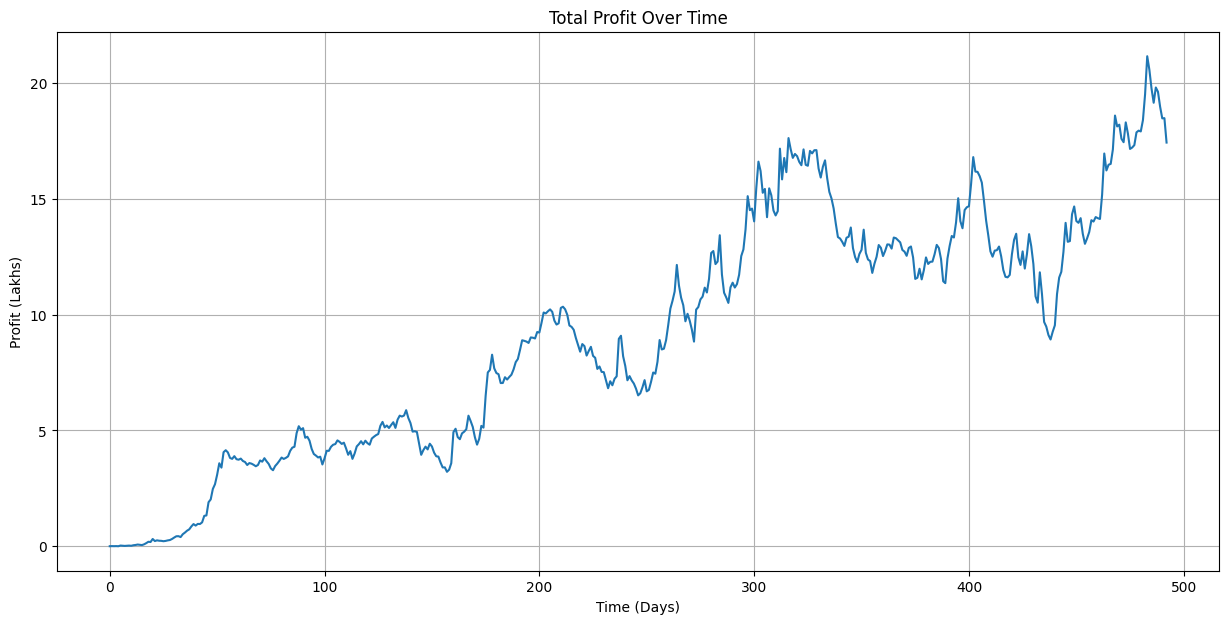

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))
plt.plot(range(len(profit_normal_trading)), profit_normal_trading['Total']/100000)
plt.title('Total Profit Over Time')
plt.xlabel('Time (Days)')
plt.ylabel('Profit (Lakhs)')
plt.grid(True)
plt.show()


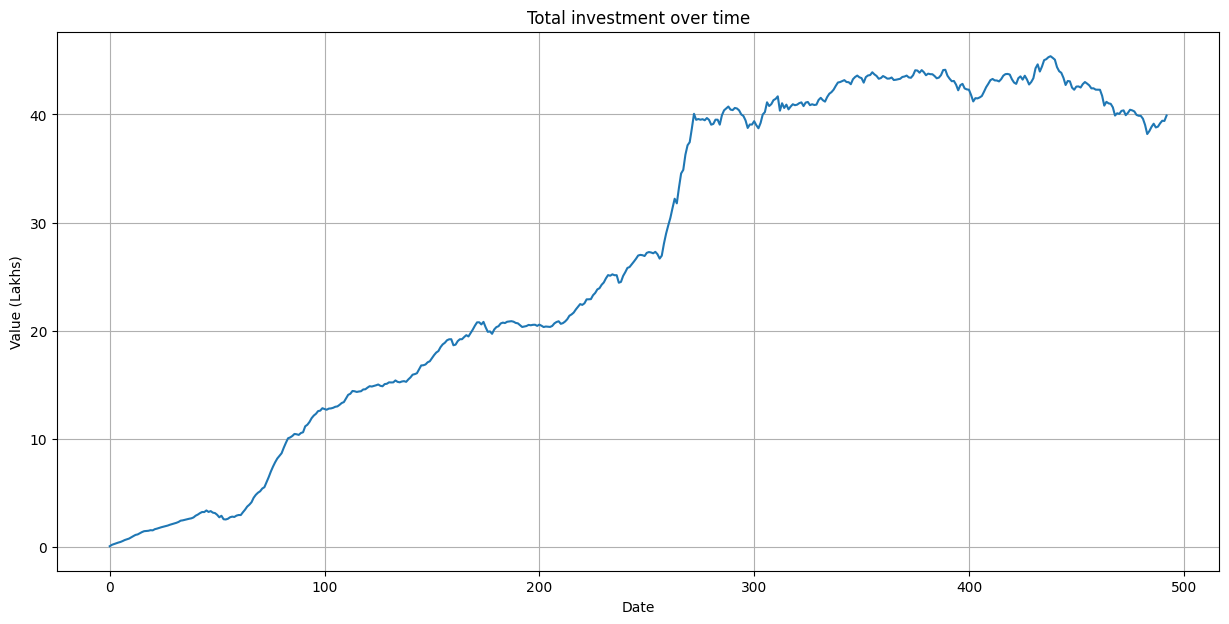

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))
plt.plot(curr_portfolio.index, curr_portfolio.sum(axis=1)/100000)
plt.title('Total investment over time')
plt.xlabel('Date')
plt.ylabel('Value (Lakhs)')
plt.grid(True)
plt.show()


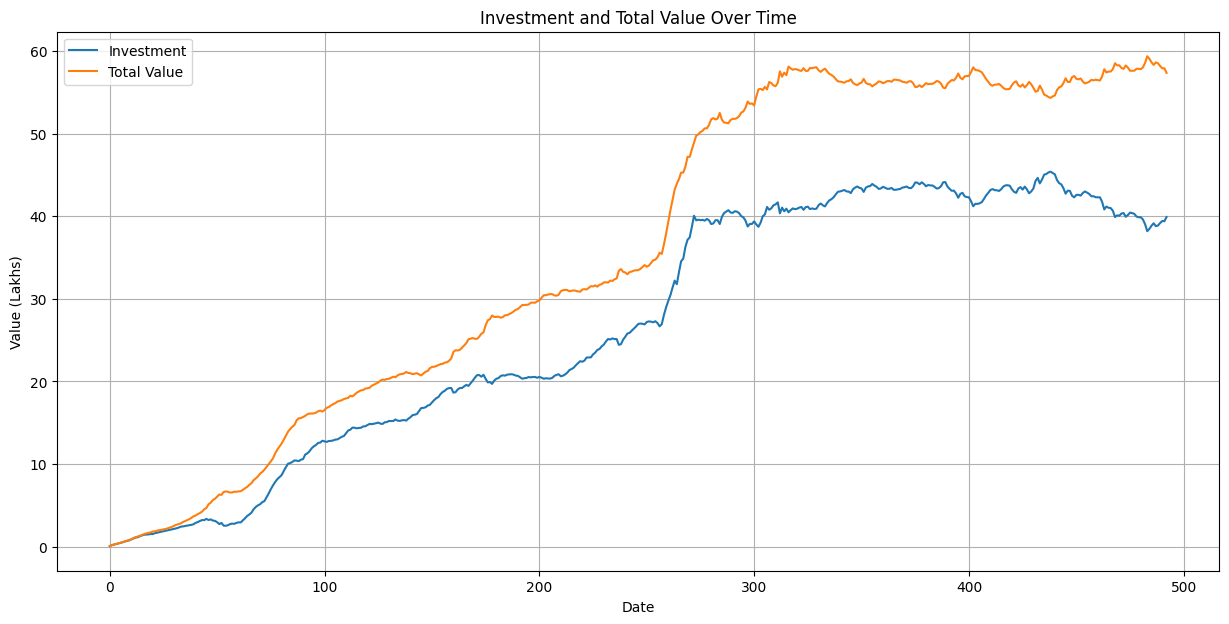

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))
plt.plot(curr_portfolio.index, curr_portfolio.sum(axis=1)/100000, label='Investment')
plt.plot(curr_portfolio.index, (curr_portfolio.sum(axis=1) + profit_normal_trading['Total'])/100000, label='Total Value')
plt.title('Investment and Total Value Over Time')
plt.xlabel('Date')
plt.ylabel('Value (Lakhs)')
plt.grid(True)
plt.legend()
plt.show()
